# Data Exploration

In this notebook, we explore the listening behavior of high-activity U.S. Last.fm users by analyzing Spotify audio features merged with their top tracks. We compute each user's **genre diversity** (the number of unique genres they listen to) and visualize patterns using histograms, scatterplots, boxplots, and correlation heatmaps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data

We load the `user_features` dataset created earlier and merge Last.fm top tracks with Spotify metadata so we can compute **genre diversity** for each user.


In [2]:
user_features = pd.read_csv("data/user_features.csv", index_col="user_id")
users = pd.read_csv("data/users.csv")

top_tracks = pd.read_csv("data/user_top_tracks.csv")
spotify = pd.read_csv("data/spotify_dataset.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'data/user_features.csv'

## Computing Genre Diversity

Genre diversity measures how many unique genres a user listens to across their top tracks. To compute this, we merge users' top tracks with Spotify’s genre metadata and count distinct genres per user.

In [ ]:
users = users[users["total_scrobbles"] > 150000].copy()
users = users[users["country"] == "United States"]
top_user_ids = set(users["user_id"])

top_tracks  = top_tracks[top_tracks["user_id"].isin(top_user_ids)]

top_tracks["track_name"] = top_tracks["track_name"].str.lower().str.strip()
top_tracks["artist_name"] = top_tracks["artist_name"].str.lower().str.strip()

spotify["song"] = spotify["song"].str.lower().str.strip()
spotify["Artist(s)"] = spotify["Artist(s)"].str.lower().str.strip()
spotify["Genre"] = spotify["Genre"].str.lower().str.strip()

merged = top_tracks.merge(
    spotify,
    left_on=["track_name", "artist_name"],
    right_on=["song", "Artist(s)"],
    how="inner"
)
genre_diversity = merged.groupby("user_id")["Genre"].nunique()

user_features["genre_diversity"] = genre_diversity


## Summary Statistics

We use `.head()` and `.describe()` to examine the structure of the user feature data and summarize central tendencies of Spotify audio features.


In [ ]:
user_features.head()
user_features.describe()
user_features.shape


(14063, 22)

## Distributions of Spotify Audio Features

We visualize the distribution of key Spotify audio features (Energy, Danceability, Tempo, Acousticness, Instrumentalness, Popularity). This helps us understand overall user listening patterns.


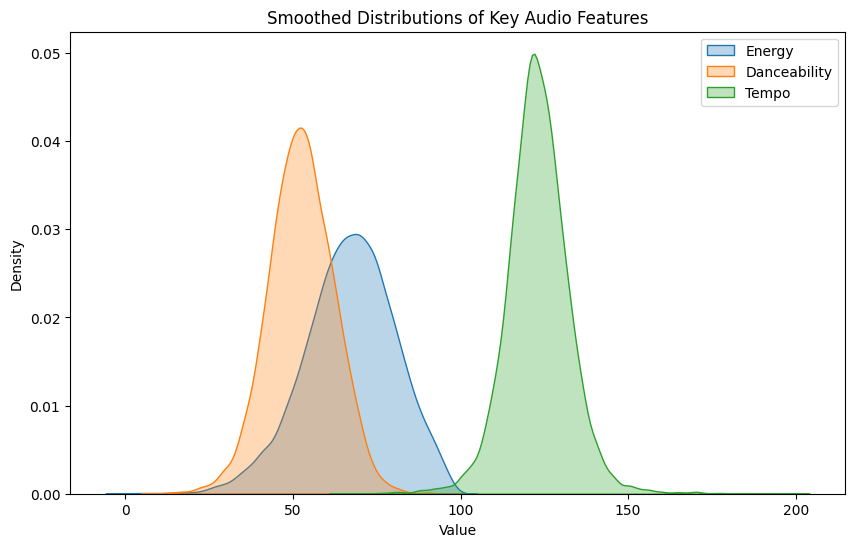

In [ ]:
plt.figure(figsize=(10, 6))
for f in ["Energy", "Danceability", "Tempo"]:
    sns.kdeplot(user_features[f], label=f, fill=True, alpha=0.3)

plt.title("Smoothed Distributions of Key Audio Features")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()


## Correlation Between Spotify Features

We compute the correlation matrix to examine how Spotify audio features relate to each other.

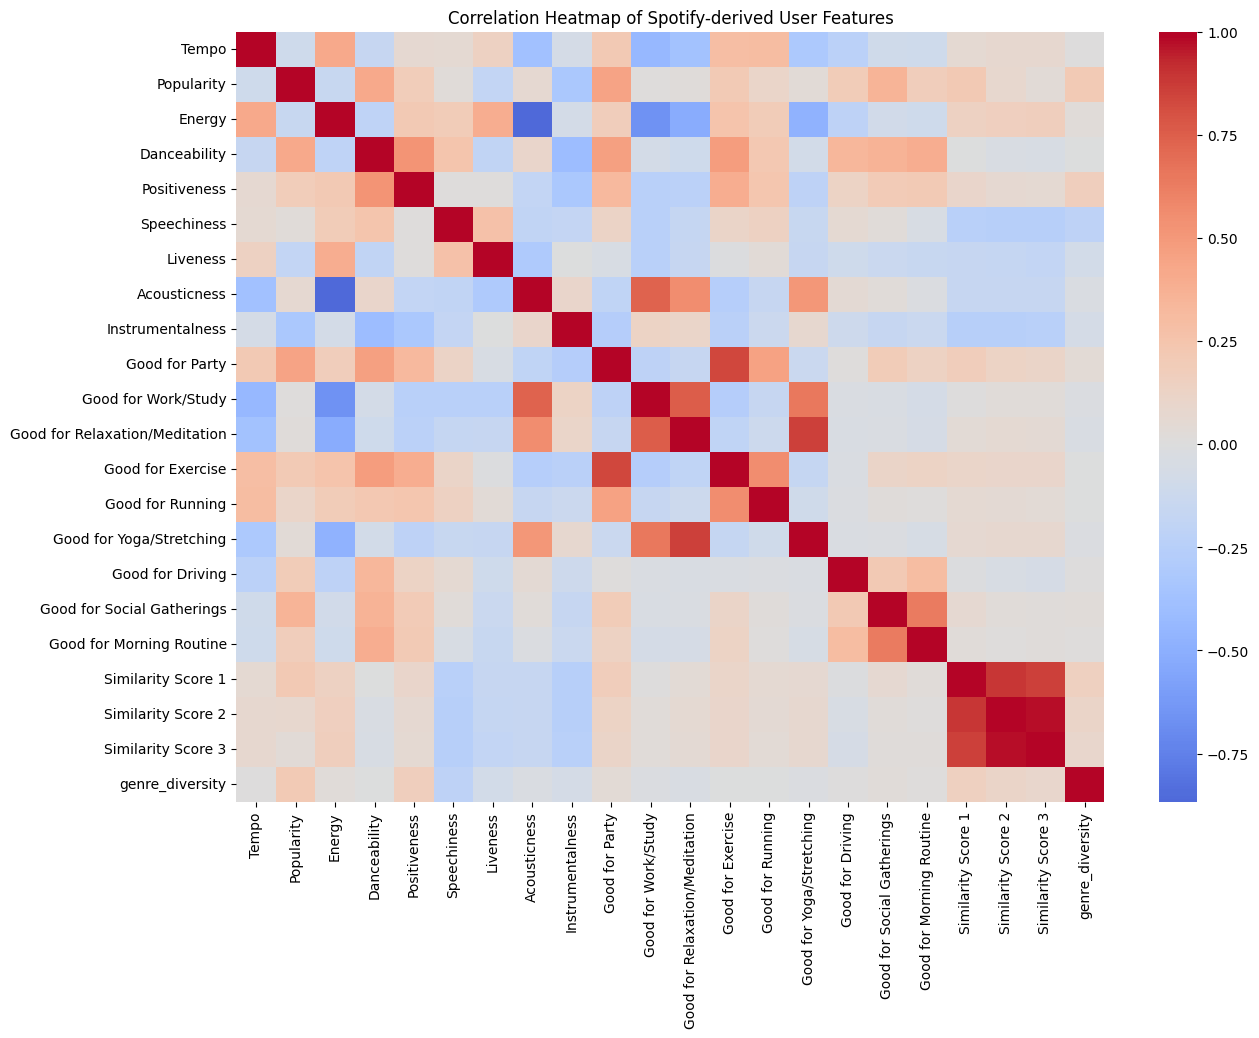

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(user_features.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Spotify-derived User Features")
plt.show()


## Distribution of Genre Diversity

We examine how many unique genres each user listens to. This reveals how varied listeners' tastes are.


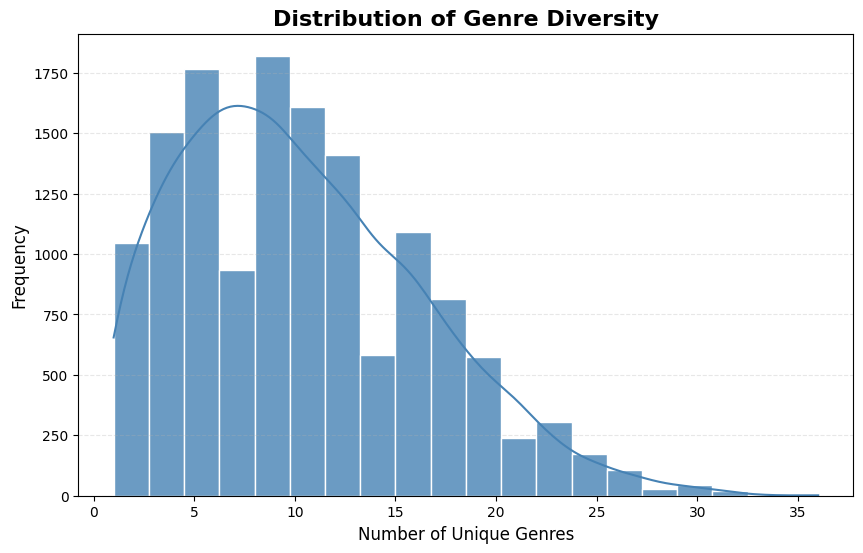

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    user_features["genre_diversity"],
    bins=20,
    kde=True, 
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)

plt.title("Distribution of Genre Diversity", fontsize=16, weight='bold')
plt.xlabel("Number of Unique Genres", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


## High vs Low Genre Diversity Groups

We split users into high- and low-genre-diversity groups using the median as a cutoff. This creates a categorical variable for comparing user behavior.


In [ ]:
threshold = user_features["genre_diversity"].median()
user_features["high_genre_diversity"] = (user_features["genre_diversity"] > threshold).astype(int)

## Relationship Between Genre Diversity and Audio Features

We use scatterplots to explore how genre diversity relates to Spotify audio features such as Energy.


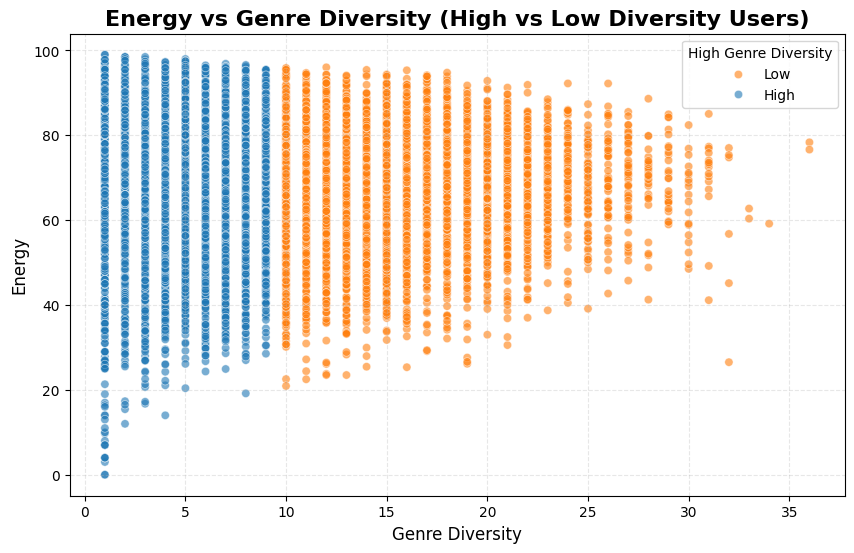

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=user_features,
    x="genre_diversity",
    y="Energy",
    hue="high_genre_diversity",
    palette=["#1f77b4", "#ff7f0e"],
    alpha=0.6
)

plt.title("Energy vs Genre Diversity (High vs Low Diversity Users)", fontsize=16, weight="bold")
plt.xlabel("Genre Diversity", fontsize=12)
plt.ylabel("Energy", fontsize=12)
plt.legend(title="High Genre Diversity", labels=["Low", "High"])
plt.grid(alpha=0.3, linestyle="--")
plt.show()


## Comparing High vs Low Genre Diversity Users

Using boxplots, we compare Spotify features between high- and low-diversity users to identify possible behavioral differences.


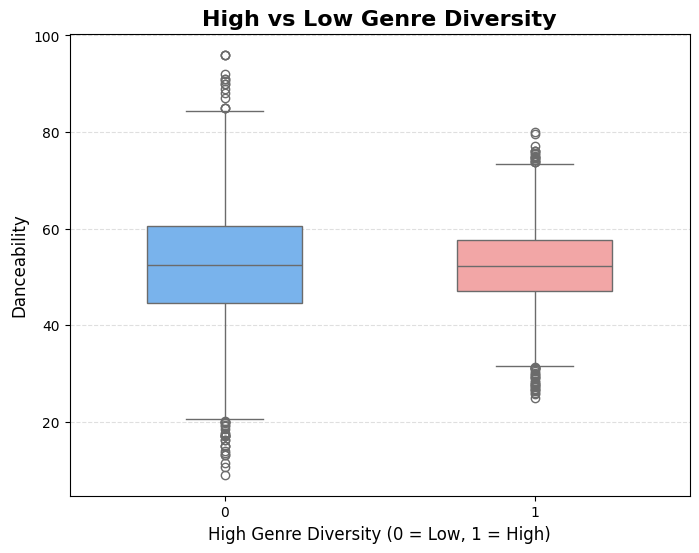

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=user_features,
    x="high_genre_diversity",
    y="Danceability",
    hue="high_genre_diversity",
    palette=["#66b3ff", "#ff9999"],
    width=0.5,
    legend=False
)

plt.title("High vs Low Genre Diversity", fontsize=16, weight="bold")
plt.xlabel("High Genre Diversity (0 = Low, 1 = High)", fontsize=12)
plt.ylabel("Danceability", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()
